
#  Handling Imbalanced Datasets

- In many real-world problems such as fraud detection or medical diagnosis, the number of positive cases is much smaller than the number of negative ones. This type of situation is called **class imbalance**.

- Machine learning models trained on such data often favor the majority class. As a result, they may perform poorly on the minority class, which is typically more important.

### Example 1: Breast Cancer Dataset

* The breast cancer dataset from `scikit-learn` contains measurements from breast tumor samples. 
* Each sample includes 30 numeric features describing properties of cell nuclei in medical images, such as radius, texture, and symmetry.

The target variable indicates diagnosis:
* `0`: Malignant
* `1`: Benign

Although the imbalance is not extreme (~63% benign, ~37% malignant), it is enough to demonstrate how a model can favor the majority class and why proper handling and evaluation are important.

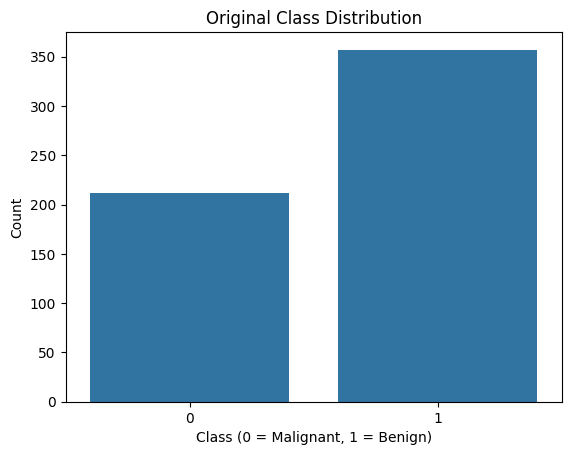

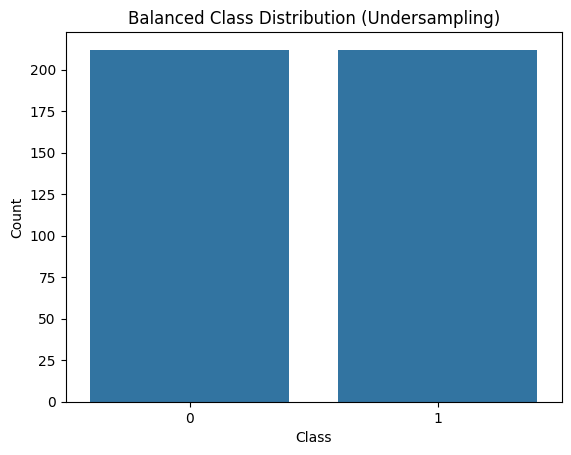

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the breast cancer dataset from scikit-learn
data = load_breast_cancer()

# X = features, y = target labels (0 = malignant, 1 = benign)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

# Combine for easier undersampling
df = pd.concat([X, y], axis=1)

# Show original class distribution
sns.countplot(x="Target", data=df)
plt.title("Original Class Distribution")
plt.xlabel("Class (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")
plt.show()

# Separate majority and minority classes
majority = df[df["Target"] == 1]  # benign
minority = df[df["Target"] == 0]  # malignant

# Randomly select the same number of samples from the majority class (benign) as there are in the minority class (malignant)
# Example:
# If the minority class has 212 samples and the majority has 357, 212 benign samples will be randomly selected from the 357 available.
# As a result, 'majority_downsampled' will contain only those 212 benign samples.
majority_downsampled = majority.sample(n=len(minority), random_state=42)

# Combine the downsampled majority (benign) and all minority (malignant) samples (pd.concat() merges both groups into one DataFrame)
# sample(frac=1) shuffles the rows so that class order is randomized
# random_state=42 ensures the shuffle is reproducible
# reset_index(drop=True) resets the row numbers and removes the old index
# The resulting 'df_balanced' DataFrame contains an equal number of benign and malignant samples
df_balanced = (
    pd.concat([majority_downsampled, minority])
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

# Visualize the balanced class distribution
sns.countplot(x="Target", data=df_balanced)
plt.title("Balanced Class Distribution (Undersampling)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()